LINEAR REGRESSION, FEATURE SCALING AND ENCODING

Dataset loaded successfully!

Dataset Shape:
(50000, 21)

First 5 Rows:
   Gender       City CollegeTier      Stream Specialisation Hostel  \
0  Female      Delhi       Tier3          IT    DataScience    Yes   
1    Male    Chennai       Tier2         ECE             AI    Yes   
2  Female  Hyderabad       Tier3         ECE     Networking     No   
3  Female     Jaipur       Tier3         ECE       Embedded     No   
4    Male  Ahmedabad       Tier3  Mechanical    DataScience     No   

  HistoryOfBacklogs  CGPA  AttendancePercent  Internships  ...  Workshops  \
0               Yes  6.63               68.3            2  ...        0.0   
1                No  6.40               71.0            1  ...        0.0   
2                No  7.73               75.1            1  ...        2.0   
3                No  9.73               99.2            4  ...        5.0   
4                No  9.01               99.6            2  ...        NaN

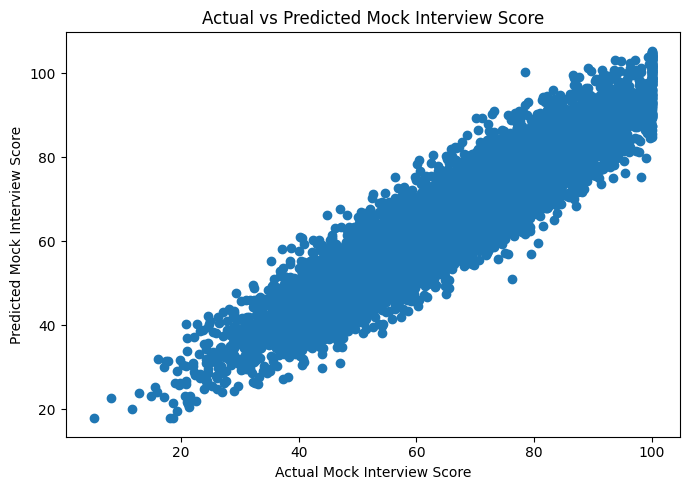


FINAL CONCLUSION

The Placement dataset was used to build a
Linear Regression model.

Target Variable:
MockInterviewScore

The pipeline performed:

1. Missing Value Imputation
2. Feature Scaling
3. Categorical Feature Encoding
4. Linear Regression

The model was evaluated using:

1. MSE
2. RMSE
3. MAE
4. R² Score

FINAL RESULTS

MSE : 37.0912
RMSE: 6.0903
MAE : 4.8459
R²  : 0.8574



In [2]:
# ============================================================
# LINEAR REGRESSION, FEATURE SCALING AND ENCODING PROJECT
# Dataset: placement_predict_50k_adjusted(1).csv
# Target: MockInterviewScore
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ------------------------------------------------------------
# 2. CONFIGURATION
# ------------------------------------------------------------

RANDOM_STATE = 42

DATA_PATH = "placement_predict_50k_adjusted.csv"


# ------------------------------------------------------------
# 3. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("LINEAR REGRESSION, FEATURE SCALING AND ENCODING")
print("=" * 60)

print("\nDataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ------------------------------------------------------------
# 4. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

# Target = MockInterviewScore

df = df.dropna(
    subset=["MockInterviewScore"]
)

X = df.drop(
    columns=[
        "MockInterviewScore",
        "IsAnomaly"
    ],
    errors="ignore"
)

y = df["MockInterviewScore"]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


# ------------------------------------------------------------
# 5. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ------------------------------------------------------------

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("\nNumerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))


# ------------------------------------------------------------
# 6. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# ------------------------------------------------------------
# 7. CREATE PREPROCESSING PIPELINE
# ------------------------------------------------------------

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 8. CREATE LINEAR REGRESSION PIPELINE
# ------------------------------------------------------------

model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "linear_regression",
            LinearRegression()
        )
    ]
)

print("\nLinear Regression Pipeline Created Successfully!")


# ------------------------------------------------------------
# 9. TRAIN MODEL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING LINEAR REGRESSION MODEL")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Model trained successfully!")


# ------------------------------------------------------------
# 10. MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = model.predict(
    X_test
)


# ------------------------------------------------------------
# 11. MODEL EVALUATION
# ------------------------------------------------------------

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)


print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("MAE :", round(mae, 4))
print("R²  :", round(r2, 4))


# ------------------------------------------------------------
# 12. ACTUAL VS PREDICTED VALUES
# ------------------------------------------------------------

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\n" + "=" * 60)
print("ACTUAL VS PREDICTED VALUES")
print("=" * 60)

print(results.head(10))


# ------------------------------------------------------------
# 13. VISUALIZE ACTUAL VS PREDICTED
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Mock Interview Score")
plt.ylabel("Predicted Mock Interview Score")

plt.title(
    "Actual vs Predicted Mock Interview Score"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 14. FINAL CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)

print(f"""
The Placement dataset was used to build a
Linear Regression model.

Target Variable:
MockInterviewScore

The pipeline performed:

1. Missing Value Imputation
2. Feature Scaling
3. Categorical Feature Encoding
4. Linear Regression

The model was evaluated using:

1. MSE
2. RMSE
3. MAE
4. R² Score

FINAL RESULTS

MSE : {mse:.4f}
RMSE: {rmse:.4f}
MAE : {mae:.4f}
R²  : {r2:.4f}
""")

print("=" * 60)